<a href="https://colab.research.google.com/github/KarAnalytics/code_demos/blob/main/LangGraph_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> **Estimated run time:** ~8 minutes (multiple graph executions + LLM calls)


This notebook demonstrates how **LangGraph** lets you build RAG pipelines as **explicit stateful graphs**. Unlike LangChain's chain abstraction where steps are implicit, LangGraph makes every step a visible **node** connected by **edges** — giving you full control over the flow.

**How it works:**
- Load **synthetic company documents** from three separate directories.
- Build a FAISS vector store (same as the LangChain notebook).
- Define a **graph** with three nodes: `retrieve` → `generate` → `format_answer`.
- Run questions through the graph and compare **with RAG** vs. **without RAG**.

**Why LangGraph?**
- Each step in your pipeline is a **node** — easy to debug, test, and modify independently
- **State** flows through the graph, so you can inspect what each node produced
- You can add **conditional edges** (e.g., route to different retrievers based on the question)
- Natural fit for **agentic workflows** where the LLM decides what to do next

**Provider setup:** This notebook uses the `llm_cascade` package, which auto-detects your API keys and falls back to the next provider if one is unavailable. Supported providers: OpenAI, Gemini, Ollama, Grok (xAI), Groq, HuggingFace, Cohere, OpenRouter.

LangGraph sits on top of the same LangChain primitives you saw in Chapter 8's `langchain_demo.ipynb` — the retriever, embeddings, and prompts are unchanged; what changes is that the linear LCEL pipe gets promoted into an explicit graph you can branch and loop over.

In [1]:
!pip install -q -U langgraph langchain langchain-community langchain-huggingface langchain-text-splitters faiss-cpu google-genai openai langchain-google-genai git+https://github.com/KarAnalytics/llm_cascade.git sentence-transformers

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.7/173.7 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 84.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 783.6/783.6 kB 64.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 50.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.6/240.6 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 7.6 MB/s eta 0:00:00
   ━━━━━

## Imports and Provider Helpers (7-Vendor Cascade)

Same provider cascade used across all our RAG notebooks. By this point the setup should feel familiar -- and that is intentional. The infrastructure layer (API keys, provider fallback, embeddings) stays constant across LlamaIndex, LangChain, and LangGraph notebooks so you can focus on what changes: the orchestration pattern. LangGraph's contribution is not a new way to call LLMs, but a new way to structure the flow between calls.

In [2]:
from pathlib import Path
from llm_cascade.providers import PROVIDERS, _load_env, _get_key, _is_retriable_error

_load_env()

def get_available_providers():
    return [p for p in PROVIDERS if _get_key(p['key_env'])]

def has_llm_provider():
    return len(get_available_providers()) > 0

# Print status
available = get_available_providers()
if available:
    print('Providers configured (in fallback order):')
    for p in available:
        print(f"  + {p['name']:<16} model = {p['default_model']}")
else:
    print('WARNING: No API keys found.')

Providers configured (in fallback order):
  + Gemini           model = gemini-2.5-flash
  + Ollama           model = kimi-k2.5:cloud
  + Groq             model = llama-3.3-70b-versatile
  + HuggingFace      model = meta-llama/Llama-3.3-70B-Instruct
  + Cohere           model = command-a-03-2025
  + OpenRouter       model = meta-llama/llama-3.3-70b-instruct:free
  + OpenAI           model = gpt-4o-mini


## Configure LLM, Embeddings, and Build Vector Store

Same setup as the LangChain notebook: local HuggingFace embeddings + first available LLM provider. We also load documents and build the FAISS vector store here. This entire section is deliberately identical to what we did in the LangChain notebook -- the vector store, the embeddings, the document loading are all the same. The only thing that changes in LangGraph is *how we orchestrate* the retrieval and generation steps, not the steps themselves.

## Create Synthetic Company Documents

We generate **fictional documents for three companies** that the LLM has never seen in training. This ensures that correct answers can **only** come from RAG retrieval, not from parametric memory. Each company's documents live in a **separate directory**, simulating real-world data silos.

| Directory | Company | Documents |
|---|---|---|
| `acme_docs/` | Acme Analytics Inc. (BI tools, Lawrence KS) | Overview, Products, Financials, Handbook, Case Study |
| `globex_docs/` | Globex Cybersecurity Corp. (cybersecurity, Boston) | Overview, Products, Incident Report |
| `nextera_docs/` | Nextera Green Solutions (sustainability consulting, Denver) | Overview, Services, Impact Report |

In [3]:
DOCUMENTS = {
    "company_overview.txt": """ACME ANALYTICS INC. — COMPANY OVERVIEW

Acme Analytics Inc. was founded in 2019 by Dr. Sarah Chen and Marcus Rivera
in Lawrence, Kansas. The company specializes in AI-powered business intelligence
tools for mid-market companies (100–5,000 employees).

Headquarters: 1420 Jayhawk Boulevard, Lawrence, KS 66045
Employees: 287 (as of January 2026)
Annual Revenue (2025): $42.3 million
Funding: Series B ($18M raised in March 2023 from Midwest Ventures)

Mission: "To democratize data analytics so every business decision is informed
by evidence, not intuition."

The company operates three offices: Lawrence (HQ), Chicago (sales), and
Austin (engineering). CEO: Dr. Sarah Chen. CTO: Marcus Rivera. CFO: Linda Park.""",

    "products_and_services.txt": """ACME ANALYTICS — PRODUCTS AND SERVICES

1. InsightBoard Pro (Flagship Product)
   - Real-time dashboard platform with natural language query interface
   - Pricing: $49/user/month (Standard), $89/user/month (Enterprise)
   - Supports PostgreSQL, MySQL, Snowflake, BigQuery, and Redshift
   - 1,847 active enterprise customers as of Q4 2025

2. DataPipe ETL
   - Automated data pipeline builder with 200+ pre-built connectors
   - Pricing: starts at $500/month for up to 10 million records/day
   - Launched in September 2024

3. PredictIQ
   - ML-powered forecasting add-on for InsightBoard Pro
   - Pricing: $29/user/month (requires InsightBoard Pro subscription)
   - Uses proprietary time-series model trained on retail and logistics data
   - Beta launched March 2025, GA release planned for June 2026

All products include 24/7 email support. Enterprise plans include dedicated
account manager and 99.9% SLA.""",

    "q4_2025_financials.txt": """ACME ANALYTICS — Q4 2025 FINANCIAL RESULTS (CONFIDENTIAL)

Period: October 1 – December 31, 2025

Revenue:          $12.8 million (Q4) / $42.3 million (FY 2025)
Gross Margin:     78.2%
Operating Profit: $1.9 million (Q4) / $5.1 million (FY 2025)
Net Income:       $1.4 million (Q4)
Cash on Hand:     $14.7 million
Burn Rate:        Company is cash-flow positive since Q2 2025

Key Metrics:
- ARR (Annual Recurring Revenue): $48.6 million (up 34% YoY)
- Net Revenue Retention: 118%
- Customer Acquisition Cost (CAC): $8,200
- Customer Lifetime Value (LTV): $67,400
- LTV/CAC Ratio: 8.2x

Headcount grew from 241 to 287 employees during 2025.
R&D spending: 31% of revenue. Sales & Marketing: 28% of revenue.""",

    "employee_handbook_excerpt.txt": """ACME ANALYTICS — EMPLOYEE HANDBOOK (EXCERPT)

PAID TIME OFF (PTO):
- All full-time employees receive 22 days of PTO per year (accrued monthly).
- PTO increases to 27 days after 3 years of service.
- Unused PTO can be carried over (max 5 days) or paid out at year-end.
- Sick leave: 10 days per year (separate from PTO).

REMOTE WORK POLICY:
- Engineering and Data Science teams: fully remote eligible.
- Sales and Customer Success: hybrid (minimum 2 days/week in office).
- All employees may work remotely up to 4 weeks/year from any US location.
- International remote work requires VP approval and tax review.

PROFESSIONAL DEVELOPMENT:
- Annual learning budget: $2,500 per employee.
- Conference attendance: up to 2 conferences per year with manager approval.
- Tuition reimbursement: up to $5,250/year for degree programs.""",

    "customer_case_study.txt": """CUSTOMER CASE STUDY: BIGRETAIL CORP

Company: BigRetail Corp (1,200 retail stores across 38 states)
Challenge: Siloed data across POS, inventory, and CRM systems made it
impossible for regional managers to get timely insights.

Solution: Deployed InsightBoard Pro Enterprise + DataPipe ETL
- Connected 14 data sources in 3 weeks using DataPipe
- 340 regional managers now use InsightBoard daily
- Natural language queries replaced manual SQL report requests

Results (after 6 months):
- 62% reduction in time-to-insight (from 4 days to 1.5 days average)
- $3.2 million saved in inventory carrying costs
- 23% increase in regional manager satisfaction scores
- SQL report request backlog eliminated entirely

Quote from BigRetail CIO Janet Torres:
\"InsightBoard Pro transformed how our managers interact with data.
They went from waiting days for a report to asking questions in plain
English and getting answers in seconds.\"""",
}

# Write documents to disk
DOC_DIR = Path("acme_docs")
DOC_DIR.mkdir(exist_ok=True)

for filename, content in DOCUMENTS.items():
    (DOC_DIR / filename).write_text(content, encoding="utf-8")

print(f"Created {len(DOCUMENTS)} documents in '{DOC_DIR}/':")
for f in sorted(DOC_DIR.iterdir()):
    print(f"  {f.name} ({f.stat().st_size} bytes)")

Created 5 documents in 'acme_docs/':
  company_overview.txt (715 bytes)
  customer_case_study.txt (924 bytes)
  employee_handbook_excerpt.txt (828 bytes)
  products_and_services.txt (915 bytes)
  q4_2025_financials.txt (709 bytes)


In [4]:
# --- Company 2: Globex Cybersecurity Corp. → globex_docs/ ---

GLOBEX_DOCUMENTS = {
    "globex_overview.txt": """GLOBEX CYBERSECURITY CORP. — COMPANY OVERVIEW

Globex Cybersecurity Corp. was founded in 2017 by former NSA analyst
James Whitfield and AI researcher Dr. Priya Narayanan in Boston, Massachusetts.
The company provides AI-driven cybersecurity solutions for financial services
and healthcare organizations.

Headquarters: 88 Federal Street, Suite 1200, Boston, MA 02110
Employees: 412 (as of January 2026)
Annual Revenue (2025): $78.5 million
Funding: Series C ($45M raised in June 2024 from CyberVentures Capital
and Goldman Sachs Growth Equity)

Mission: "To make enterprise-grade cybersecurity autonomous, adaptive,
and accessible to every regulated industry."

The company operates four offices: Boston (HQ), Washington D.C. (government
relations), Tel Aviv (R&D), and Singapore (APAC sales).
CEO: James Whitfield. CTO: Dr. Priya Narayanan. CISO: Robert Tanaka.""",

    "globex_products.txt": """GLOBEX CYBERSECURITY — PRODUCTS AND SERVICES

1. ShieldAI Platform (Flagship Product)
   - AI-powered threat detection and automated incident response
   - Uses behavioral analysis to detect zero-day attacks in real time
   - Pricing: $120/endpoint/year (Standard), $195/endpoint/year (Premium)
   - 623 enterprise customers across 18 countries as of Q4 2025
   - Average detection time: 2.3 minutes (industry average: 197 days)

2. VaultGuard
   - Data encryption and access management platform for regulated industries
   - HIPAA, SOX, and PCI-DSS compliant out of the box
   - Pricing: $35,000/year (up to 500 users), $60,000/year (unlimited users)
   - Launched January 2023

3. ThreatIntel Live
   - Real-time threat intelligence feed with dark web monitoring
   - Pricing: $8,500/month (includes API access and analyst dashboard)
   - Aggregates data from 2,400+ sources updated every 15 minutes
   - Integrates with Splunk, CrowdStrike, Palo Alto, and Microsoft Sentinel

All products include a dedicated Security Operations Center (SOC) team for
Premium customers. Globex holds ISO 27001 and SOC 2 Type II certifications.""",

    "globex_incident_report.txt": """GLOBEX CYBERSECURITY — 2025 THREAT LANDSCAPE REPORT (PUBLIC)

Published: February 2026

KEY FINDINGS FROM GLOBEX'S CUSTOMER BASE (2025):

Total incidents analyzed: 14,237 across 623 customers
- Ransomware attacks: up 42% YoY (3,891 incidents)
- Phishing campaigns: up 28% YoY (5,102 incidents)
- Supply chain attacks: up 67% YoY (1,245 incidents — fastest-growing category)
- Insider threats: relatively stable at 1,834 incidents

ShieldAI Platform Performance:
- Blocked 97.3% of attacks before any data exfiltration
- Mean time to detect (MTTD): 2.3 minutes
- Mean time to respond (MTTR): 8.7 minutes (automated response)
- False positive rate: 0.4% (down from 1.2% in 2024)

NOTABLE CASE: MERIDIAN HEALTH SYSTEM
- 340-bed hospital network targeted by Medusa ransomware variant
- ShieldAI detected anomalous lateral movement within 47 seconds
- Automated containment isolated 3 affected servers in under 2 minutes
- Zero patient data exfiltrated; zero downtime for clinical systems
- Estimated savings: $12M+ (average healthcare ransomware cost per Ponemon)

INDUSTRY PREDICTIONS FOR 2026:
- AI-generated phishing emails will become indistinguishable from human-written
- Quantum-resistant encryption adoption will begin in financial services
- Average cost of a data breach expected to exceed $5.2 million globally""",
}

GLOBEX_DIR = Path("globex_docs")
GLOBEX_DIR.mkdir(exist_ok=True)

for filename, content in GLOBEX_DOCUMENTS.items():
    (GLOBEX_DIR / filename).write_text(content, encoding="utf-8")

print(f"Created {len(GLOBEX_DOCUMENTS)} documents in '{GLOBEX_DIR}/':")
for f in sorted(GLOBEX_DIR.iterdir()):
    print(f"  {f.name} ({f.stat().st_size} bytes)")

Created 3 documents in 'globex_docs/':
  globex_incident_report.txt (1321 bytes)
  globex_overview.txt (864 bytes)
  globex_products.txt (1131 bytes)


In [5]:
# --- Company 3: Nextera Green Solutions → nextera_docs/ ---

NEXTERA_DOCUMENTS = {
    "nextera_overview.txt": """NEXTERA GREEN SOLUTIONS — COMPANY OVERVIEW

Nextera Green Solutions was founded in 2020 by climate scientist Dr. Elena
Vasquez and former McKinsey partner David Okafor in Denver, Colorado.
The company provides sustainability consulting and carbon accounting software
to help companies meet ESG (Environmental, Social, Governance) targets.

Headquarters: 1700 Lincoln Street, Suite 3400, Denver, CO 80203
Employees: 156 (as of January 2026)
Annual Revenue (2025): $23.8 million
Funding: Series A ($12M raised in November 2023 from Climate Capital Partners
and Patagonia Ventures)

Mission: "To give every company a clear, data-driven path to net zero —
turning climate commitments into measurable action."

The company operates two offices: Denver (HQ) and London (European operations).
CEO: Dr. Elena Vasquez. COO: David Okafor. VP Engineering: Kenji Tanaka.
Nextera is a certified B Corporation and a member of the UN Global Compact.""",

    "nextera_services.txt": """NEXTERA GREEN SOLUTIONS — SERVICES AND PLATFORM

1. CarbonLens Platform (Flagship Product)
   - Automated Scope 1, 2, and 3 carbon emissions tracking
   - Integrates with ERP systems (SAP, Oracle, NetSuite) to pull real data
   - AI-powered recommendations for emission reduction strategies
   - Pricing: $2,500/month (Standard, up to $500M revenue companies)
              $6,500/month (Enterprise, unlimited + custom reporting)
   - 312 active customers as of Q4 2025

2. ESG Reporting Suite
   - Automated generation of sustainability reports (GRI, SASB, TCFD, CDP)
   - Audit-ready documentation with full data lineage
   - Pricing: $18,000/year (bundled with CarbonLens Enterprise)
   - Standalone: $24,000/year
   - Launched April 2024

3. Sustainability Strategy Consulting
   - Science-Based Targets initiative (SBTi) alignment services
   - Supply chain decarbonization roadmaps
   - Pricing: Project-based ($75,000 – $250,000 per engagement)
   - Team of 28 consultants with backgrounds in climate science and industry

4. Carbon Offset Marketplace
   - Verified carbon credits from 45 projects across 12 countries
   - Blockchain-verified chain of custody for each credit
   - Transaction fee: 4.5% per credit purchase
   - Beta launched August 2025

All platform customers receive quarterly sustainability benchmarking reports
comparing their performance against industry peers.""",

    "nextera_impact_report.txt": """NEXTERA GREEN SOLUTIONS — 2025 IMPACT REPORT

Published: January 2026

COMPANY IMPACT METRICS:
- Total customer carbon emissions tracked: 47.3 million metric tons CO2e
- Verified emission reductions enabled: 6.8 million metric tons CO2e (14.4%)
- Customers who improved their CDP score after using Nextera: 89%
- Average time to produce ESG report reduced from 14 weeks to 3.5 weeks

NOTABLE CLIENT RESULTS:

1. SummitBrew Coffee (specialty coffee chain, 380 locations)
   - Reduced Scope 3 supply chain emissions by 31% in 18 months
   - Switched 62% of logistics to electric vehicles using Nextera roadmap
   - First coffee chain to achieve SBTi-validated near-term target

2. Pacific Northwest Lumber Co. (timber and building materials)
   - Used CarbonLens to discover 40% of emissions came from transportation
   - Optimized shipping routes: saved 8,200 metric tons CO2e and $1.4M/year
   - Achieved carbon-neutral certification for 2025 operations

3. Meridian Financial Group (regional bank, $8B assets)
   - Implemented financed emissions tracking (PCAF methodology)
   - Identified $2.1B in loan portfolio exposed to high transition risk
   - Developed green lending program: $340M in sustainability-linked loans

AWARDS AND RECOGNITION (2025):
- Fast Company "Most Innovative Companies" — Energy category (#7)
- B Corp "Best for the World" — Environment category
- Colorado Governor's Award for Clean Energy Innovation""",
}

NEXTERA_DIR = Path("nextera_docs")
NEXTERA_DIR.mkdir(exist_ok=True)

for filename, content in NEXTERA_DOCUMENTS.items():
    (NEXTERA_DIR / filename).write_text(content, encoding="utf-8")

print(f"Created {len(NEXTERA_DOCUMENTS)} documents in '{NEXTERA_DIR}/':")
for f in sorted(NEXTERA_DIR.iterdir()):
    print(f"  {f.name} ({f.stat().st_size} bytes)")

Created 3 documents in 'nextera_docs/':
  nextera_impact_report.txt (1434 bytes)
  nextera_overview.txt (938 bytes)
  nextera_services.txt (1394 bytes)


In [6]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.chat_models import ChatOpenAI

# ---- Embedding model (local, no API key needed) -----------------------------
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
print("Embedding model: sentence-transformers/all-MiniLM-L6-v2 (local)")

# ---- LLM with runtime fallback (cascades if quota is exhausted) --------------
llm_candidates = []
for provider in get_available_providers():
    api_key = _get_key(provider["key_env"])
    try:
        if provider["style"] == "gemini":
            from langchain_google_genai import ChatGoogleGenerativeAI
            candidate = ChatGoogleGenerativeAI(
                google_api_key=api_key,
                model=provider["default_model"],
            )
        else:
            candidate = ChatOpenAI(
                api_key=api_key,
                base_url=provider["base_url"],
                model=provider["default_model"],
            )
        llm_candidates.append((provider, candidate))
        print(f"  + {provider['name']:<16} ({provider['default_model']})")
    except Exception as e:
        print(f"  - {provider['name']:<16} skipped: {e}")

if llm_candidates:
    primary_provider, primary_llm = llm_candidates[0]
    fallback_llms = [c for _, c in llm_candidates[1:]]

    if fallback_llms:
        llm = primary_llm.with_fallbacks(fallback_llms)
        print(f"\nPrimary LLM: {primary_provider['name']} ({primary_provider['default_model']})")
        print(f"Fallbacks:   {', '.join(p['name'] for p, _ in llm_candidates[1:])}")
        print("(If primary hits quota, automatically tries the next provider)")
    else:
        llm = primary_llm
        print(f"\nLLM provider: {primary_provider['name']} ({primary_provider['default_model']})")
        print("(No fallback providers configured)")

    llm_provider = primary_provider
else:
    llm = None
    primary_llm = None
    llm_provider = None
    print("ERROR: Could not configure any LLM provider. Check your API keys.")

# ---- Load documents from three company directories --------------------------
from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

DOC_DIRS = {
    "acme_docs":    "Acme Analytics (BI tools)",
    "globex_docs":  "Globex Cybersecurity (security)",
    "nextera_docs": "Nextera Green Solutions (sustainability)",
}

all_docs = []
for dir_name, label in DOC_DIRS.items():
    loader = DirectoryLoader(dir_name, glob="**/*.txt", loader_cls=TextLoader,
                             loader_kwargs={"encoding": "utf-8"})
    docs = loader.load()
    print(f"  Loaded: '{dir_name}/' -> {len(docs)} docs  [{label}]")
    all_docs.extend(docs)

# ---- Split and index --------------------------------------------------------
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000, chunk_overlap=200,
    separators=["\n---\n", "\n\n", "\n", " "],
)
chunks = text_splitter.split_documents(all_docs)

vectorstore = FAISS.from_documents(chunks, embeddings)
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})
print(f"FAISS vector store: {len(chunks)} chunks indexed, retriever ready (top_k=3)")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model: sentence-transformers/all-MiniLM-L6-v2 (local)
  + Gemini           (gemini-2.5-flash)


/tmp/ipykernel_6060/2431139388.py:20: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the `langchain-openai package and should be used instead. To use it run `pip install -U `langchain-openai` and import as `from `langchain_openai import ChatOpenAI``.
  candidate = ChatOpenAI(


  + Ollama           (kimi-k2.5:cloud)
  + Groq             (llama-3.3-70b-versatile)
  + HuggingFace      (meta-llama/Llama-3.3-70B-Instruct)
  + Cohere           (command-a-03-2025)
  + OpenRouter       (meta-llama/llama-3.3-70b-instruct:free)
  + OpenAI           (gpt-4o-mini)

Primary LLM: Gemini (gemini-2.5-flash)
Fallbacks:   Ollama, Groq, HuggingFace, Cohere, OpenRouter, OpenAI
(If primary hits quota, automatically tries the next provider)
  Loaded: 'acme_docs/' -> 5 docs  [Acme Analytics (BI tools)]
  Loaded: 'globex_docs/' -> 3 docs  [Globex Cybersecurity (security)]
  Loaded: 'nextera_docs/' -> 3 docs  [Nextera Green Solutions (sustainability)]
FAISS vector store: 15 chunks indexed, retriever ready (top_k=3)


## Define the RAG Graph

This is where LangGraph diverges from LangChain. Instead of composing steps with the `|` pipe operator, we build an **explicit graph** where each step is a **node** and the connections between them are **edges**. The state that flows through the graph is defined as a Python `TypedDict` -- a plain dictionary with typed fields like `question`, `context`, `answer`, and `sources`. Every node is a function that reads from this state dict and writes back to it.

| Node | What it does |
|---|---|
| `retrieve` | Searches the vector store for relevant chunks |
| `generate` | Sends the question + retrieved chunks to the LLM |

The graph flows: **START --> retrieve --> generate --> END**

Why bother with a graph for what is essentially a two-step pipeline? Because this simple linear graph is a stepping stone. Once you have the graph infrastructure in place, adding conditional branches, retry loops, or parallel paths is just a matter of adding nodes and edges -- no restructuring required. The linear graph teaches you the API; the conditional and looping graphs that follow show why it matters.

```
START --> retrieve --> generate --> END
```


In [7]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# ---------------------------------------------------------------------------
# Step 1: Define the STATE that flows through the graph
# ---------------------------------------------------------------------------
class RAGState(TypedDict):
    question: str           # user's question (input)
    context: str            # retrieved chunks (set by retrieve node)
    sources: list[str]      # source file names (set by retrieve node)
    answer: str             # LLM's answer (set by generate node)


# ---------------------------------------------------------------------------
# Step 2: Define the NODES (each is a plain function)
# ---------------------------------------------------------------------------
def retrieve(state: RAGState) -> dict:
    """Search the vector store for relevant chunks."""
    docs = retriever.invoke(state["question"])
    context = "\n\n---\n\n".join(doc.page_content for doc in docs)
    sources = list(set(doc.metadata.get("source", "unknown") for doc in docs))
    return {"context": context, "sources": sources}


def generate(state: RAGState) -> dict:
    """Send question + retrieved context to the LLM."""
    prompt = f"""Answer the question based ONLY on the following context.
If the context doesn't contain the answer, say "I don't have enough information."

Context:
{state['context']}

Question: {state['question']}

Answer:"""
    response = llm.invoke(prompt)
    return {"answer": response.content}


# ---------------------------------------------------------------------------
# Step 3: Build the GRAPH
# ---------------------------------------------------------------------------
workflow = StateGraph(RAGState)

# Add nodes
workflow.add_node("retrieve", retrieve)
workflow.add_node("generate", generate)

# Add edges: START → retrieve → generate → END
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "generate")
workflow.add_edge("generate", END)

# Compile the graph
graph = workflow.compile()
print("RAG graph compiled: START \u2192 retrieve \u2192 generate \u2192 END")

RAG graph compiled: START → retrieve → generate → END


## Visualize the RAG Graph

One of LangGraph's most practical features is built-in graph visualization. The compiled graph can render itself as a Mermaid diagram showing nodes and edges. For our simple RAG pipeline this is just a straight line (`START --> retrieve --> generate --> END`), but as we add conditional routing and loops in later sections, the diagrams become invaluable for understanding the flow at a glance.

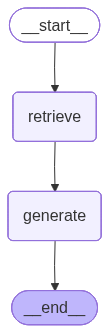

In [8]:
from IPython.display import Image, display

try:
    img_bytes = graph.get_graph().draw_mermaid_png()
    display(Image(img_bytes))
except Exception as e:
    # Fallback: print the text representation
    print("Graph structure (install graphviz for visual rendering):")
    print("  START \u2192 retrieve \u2192 generate \u2192 END")
    print(f"  (Visual rendering unavailable: {e})")

## Trace the State Through the RAG Graph

LangGraph's `.stream()` method lets you **watch state evolve** as data flows through each node. This is the key advantage over LangChain's chain abstraction: instead of a black-box pipeline that accepts a question and returns an answer, you can inspect exactly what each node contributed to the shared state dictionary.

Below, we run one question through the graph and print the state dict after every node executes. Notice how `context` and `sources` appear after the `retrieve` node, and `answer` appears after `generate`. This kind of step-by-step transparency is invaluable for debugging RAG pipelines -- when an answer is wrong, you can immediately see whether the problem is in retrieval (wrong chunks) or generation (right chunks but bad answer).

In [9]:
if has_llm_provider():
    question = "What was Acme Analytics' revenue in Q4 2025?"
    print(f'Tracing state for: "{question}"')
    print()

    for state_update in graph.stream({'question': question}):
        node_name = list(state_update.keys())[0]
        node_output = state_update[node_name]
        print('=' * 60)
        print(f'After node: {node_name}')
        print('=' * 60)
        for key, value in node_output.items():
            val_str = str(value)
            if len(val_str) > 200:
                val_str = val_str[:200] + '...'
            print(f'  state["{key}"] = {val_str}')
        print()


Tracing state for: "What was Acme Analytics' revenue in Q4 2025?"

After node: retrieve
  state["context"] = ACME ANALYTICS — Q4 2025 FINANCIAL RESULTS (CONFIDENTIAL)

Period: October 1 – December 31, 2025

Revenue:          $12.8 million (Q4) / $42.3 million (FY 2025)
Gross Margin:     78.2%
Operating Profi...
  state["sources"] = ['acme_docs/company_overview.txt', 'acme_docs/q4_2025_financials.txt', 'acme_docs/products_and_services.txt']

After node: generate
  state["answer"] = Acme Analytics' revenue in Q4 2025 was $12.8 million.



## Run the RAG Graph

Now let us run the full graph on several questions and see the end-to-end results. The graph executes `retrieve --> generate` and returns the final state with the answer, sources, and context. Compare these results to what you saw in the LangChain notebook -- the answers should be identical, because the underlying retrieval and generation logic is the same. What differs is the orchestration: here every step is a visible, inspectable node in a graph.

In [10]:
questions = [
    "What was Acme Analytics' revenue in Q4 2025?",
    #"How many days of PTO do new employees get at Acme?",
    #"What is Globex Cybersecurity's flagship product and how fast does it detect threats?",
    #"How did Globex help Meridian Health System during a ransomware attack?",
    #"Who founded Nextera Green Solutions and where is it headquartered?",
    #"How much carbon emissions reduction did Nextera enable for its customers in 2025?",
]


def preview(text, max_len=800):
    text = str(text) if text else ""
    return text[:max_len] + ("..." if len(text) > max_len else "")


if not has_llm_provider():
    print("Error: No LLM API key configured. Set at least one API key in Colab Secrets.")
else:
    for i, q in enumerate(questions, start=1):
        print("=" * 80)
        print(f"Q{i}. {q}")
        print("=" * 80)

        try:
            result = graph.invoke({"question": q})
            print(f"Model: {llm_provider['name']} ({llm_provider['default_model']})")
            print("Answer:")
            print(preview(result["answer"]))
            print(f"Sources: {', '.join(result['sources'])}")
        except Exception as e:
            if _is_retriable_error(e):
                print("  Rate limited -- skipping")
            else:
                print(f"  Error: {e}")

        print()


Q1. What was Acme Analytics' revenue in Q4 2025?
Model: Gemini (gemini-2.5-flash)
Answer:
Acme Analytics' revenue in Q4 2025 was $12.8 million.
Sources: acme_docs/company_overview.txt, acme_docs/q4_2025_financials.txt, acme_docs/products_and_services.txt



At this point you have seen LangGraph's simplest pattern: a linear graph that does the same thing as a LangChain chain or a LlamaIndex query engine. The value so far is debuggability -- you can trace state through each node. But the real power of graphs emerges when the flow is no longer linear. The next two sections demonstrate branching (conditional routing) and looping (retry with self-evaluation), which are the patterns that justify reaching for LangGraph over simpler abstractions.

## LangGraph vs. LangChain vs. LlamaIndex

| Aspect | LangGraph | LangChain | LlamaIndex |
|---|---|---|---|
| Abstraction | Graph of nodes + edges | Chains (sequential steps) | High-level query engine |
| State management | Explicit `TypedDict` state | Implicit in chain | Hidden inside framework |
| Debuggability | Inspect any node's output | Chain callbacks | Event handlers |
| Conditional logic | Conditional edges in graph | Requires custom chains | Requires custom modules |
| Visual pipeline | Built-in graph rendering | No built-in visualization | No built-in visualization |
| Complexity | Medium | Low–Medium | Low |
| Best for | Complex multi-step agents | Standard RAG pipelines | Quick document Q&A |

**Key takeaway:** LangGraph shines when you need **visibility and control** over a multi-step pipeline. The graph structure makes it easy to add conditional routing, retry logic, human-in-the-loop steps, or parallel branches — things that are harder to express as a simple chain.

---

## Beyond RAG: Conditional Routing with LangGraph

The RAG graph above is a **linear pipeline** — every question follows the same path. LangGraph’s real power emerges with **conditional edges** that route questions to different handlers based on runtime data.

Below, we build a **smart router** that:
- Uses a `classify` node to categorize each question (finance / hr / technical / general)
- Routes to a **specialized handler** via a conditional edge
- Each handler uses the same retriever but a different system prompt tuned for its domain

The graph shape is a **fan-out**: `START → classify → one-of-four handlers → END`.


In [11]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

# ---------------------------------------------------------------------------
# State for the routing graph
# ---------------------------------------------------------------------------
class RouterState(TypedDict):
    question: str
    category: str          # set by classify node
    context: str           # set by handler nodes
    sources: list[str]     # set by handler nodes
    answer: str            # set by handler nodes


# ---------------------------------------------------------------------------
# Node: classify — LLM decides which department handles the question
# ---------------------------------------------------------------------------
def classify(state: RouterState) -> dict:
    """Use the LLM to classify the question into a category."""
    classification_prompt = f"""Classify the following question into exactly ONE category.
Reply with ONLY the category name, nothing else.

Categories:
- finance: revenue, profit, costs, pricing, funding, financial metrics, ARR, burn rate
- hr: PTO, remote work, benefits, employee policies, handbook, hiring, headcount
- technical: products, features, integrations, security, technology, platform details
- general: company overview, founders, mission, headquarters, partnerships, anything else

Question: {state['question']}

Category:"""
    response = llm.invoke(classification_prompt)
    category = response.content.strip().lower()
    # Normalize to valid categories
    if category not in ("finance", "hr", "technical", "general"):
        category = "general"
    print(f"  [classify] → {category}")
    return {"category": category}


# ---------------------------------------------------------------------------
# Nodes: specialized handlers (each uses retriever + tailored system prompt)
# ---------------------------------------------------------------------------
HANDLER_PROMPTS = {
    "finance": "You are a financial analyst. Focus on numbers, metrics, and financial performance. Be precise with figures.",
    "hr": "You are an HR specialist. Focus on policies, benefits, and employee-related information. Be clear about specific rules and limits.",
    "technical": "You are a technical product expert. Focus on features, capabilities, integrations, and technical specifications.",
    "general": "You are a helpful business analyst. Provide a clear, comprehensive answer.",
}


def _make_handler(category: str):
    """Factory function to create a handler node for a given category."""
    def handler(state: RouterState) -> dict:
        docs = retriever.invoke(state["question"])
        context = "\n\n---\n\n".join(doc.page_content for doc in docs)
        sources = list(set(doc.metadata.get("source", "unknown") for doc in docs))

        system_prompt = HANDLER_PROMPTS[category]
        prompt = f"""{system_prompt}

Answer based ONLY on the following context. If the context doesn't contain the answer, say so.

Context:
{context}

Question: {state['question']}

Answer:"""
        response = llm.invoke(prompt)
        print(f"  [{category}_handler] answered using {len(docs)} chunks")
        return {"context": context, "sources": sources, "answer": response.content}
    handler.__name__ = f"{category}_handler"
    return handler


# ---------------------------------------------------------------------------
# Router function — decides which handler to call based on classification
# ---------------------------------------------------------------------------
def route_question(state: RouterState) -> str:
    """Conditional edge: route to the appropriate handler based on category."""
    return f"{state['category']}_handler"


# ---------------------------------------------------------------------------
# Build the routing graph
# ---------------------------------------------------------------------------
router_graph = StateGraph(RouterState)

# Add nodes
router_graph.add_node("classify", classify)
for cat in HANDLER_PROMPTS:
    router_graph.add_node(f"{cat}_handler", _make_handler(cat))

# Add edges
router_graph.add_edge(START, "classify")
router_graph.add_conditional_edges("classify", route_question)
for cat in HANDLER_PROMPTS:
    router_graph.add_edge(f"{cat}_handler", END)

# Compile
smart_router = router_graph.compile()
print("Smart router graph compiled!")
print("  Nodes: classify → finance_handler | hr_handler | technical_handler | general_handler")

Smart router graph compiled!
  Nodes: classify → finance_handler | hr_handler | technical_handler | general_handler


## Visualize the Routing Graph

The conditional edge from `classify` fans out to four handler nodes. At runtime, only one path is taken based on the LLM’s classification. The text diagram below the rendered graph clarifies the routing logic.


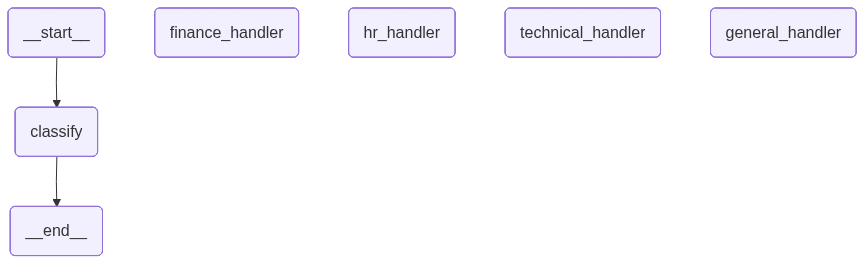

Routing logic:
  START
    └── classify (LLM classifies the question)
          ├── [finance]   → finance_handler   → END
          ├── [hr]        → hr_handler        → END
          ├── [technical] → technical_handler → END
          └── [general]   → general_handler   → END


In [12]:
from IPython.display import Image, display

try:
    img_bytes = smart_router.get_graph().draw_mermaid_png()
    display(Image(img_bytes))
except Exception as e:
    print(f"(Visual rendering unavailable: {e})")

print("Routing logic:")
print("  START")
print("    └── classify (LLM classifies the question)")
print("          ├── [finance]   → finance_handler   → END")
print("          ├── [hr]        → hr_handler        → END")
print("          ├── [technical] → technical_handler → END")
print("          └── [general]   → general_handler   → END")


## Trace the State Through the Routing Graph

Same idea as before, but now the state also carries a `category` field set by the `classify` node, and the conditional edge picks a different handler based on that category. Watch how the state evolves differently depending on which branch is taken -- the `category` field acts as a routing signal that determines which node executes next. This is the `TypedDict` state pattern in action: every decision the graph makes is recorded in the state and visible to you.

In [13]:
if has_llm_provider():
    question = "What is Acme Analytics' LTV/CAC ratio?"
    print(f'Tracing state for: "{question}"')
    print()

    for state_update in smart_router.stream({'question': question}):
        node_name = list(state_update.keys())[0]
        node_output = state_update[node_name]
        print('=' * 60)
        print(f'After node: {node_name}')
        print('=' * 60)
        for key, value in node_output.items():
            val_str = str(value)
            if len(val_str) > 200:
                val_str = val_str[:200] + '...'
            print(f'  state["{key}"] = {val_str}')
        print()


Tracing state for: "What is Acme Analytics' LTV/CAC ratio?"

  [classify] → finance
After node: classify
  state["category"] = finance

  [finance_handler] answered using 3 chunks
After node: finance_handler
  state["context"] = ACME ANALYTICS — Q4 2025 FINANCIAL RESULTS (CONFIDENTIAL)

Period: October 1 – December 31, 2025

Revenue:          $12.8 million (Q4) / $42.3 million (FY 2025)
Gross Margin:     78.2%
Operating Profi...
  state["sources"] = ['acme_docs/company_overview.txt', 'acme_docs/q4_2025_financials.txt', 'acme_docs/products_and_services.txt']
  state["answer"] = Based on the Q4 2025 financial results provided, Acme Analytics' LTV/CAC ratio is **8.2x**.

**Supporting metrics from the context:**
- Customer Lifetime Value (LTV): $67,400
- Customer Acquisition Co...



## Test the Smart Router

Each question is classified and routed to the matching handler. Uncomment questions one at a time to test different categories.


In [14]:
router_questions = [
    # Should route to finance_handler
    "What is Acme Analytics' LTV/CAC ratio?",
    #"What was Globex Cybersecurity's annual revenue in 2025?",

    # Should route to hr_handler
    #"What is Acme's remote work policy for engineers?",
    #"How much tuition reimbursement do Acme employees get?",

    # Should route to technical_handler
    #"What databases does InsightBoard Pro support?",
    #"How does Globex ShieldAI detect zero-day attacks?",

    # Should route to general_handler
    #"Who founded Nextera Green Solutions?",
    #"What awards did Nextera win in 2025?",
]


def preview(text, max_len=600):
    text = str(text) if text else ""
    return text[:max_len] + ("..." if len(text) > max_len else "")


if has_llm_provider():
    for i, q in enumerate(router_questions, start=1):
        print("\n" + "=" * 80)
        print(f"Q{i}. {q}")
        print("=" * 80)
        try:
            result = smart_router.invoke({"question": q})
            print(f"  Category: {result['category']}")
            print(f"  Answer: {preview(result['answer'])}")
            print(f"  Sources: {', '.join(result['sources'])}")
        except Exception as e:
            if _is_retriable_error(e):
                print(f"  Rate limited — skipping")
            else:
                print(f"  Error: {e}")
        print()
else:
    print("Set at least one API key first.")


Q1. What is Acme Analytics' LTV/CAC ratio?
  [classify] → finance
  [finance_handler] answered using 3 chunks
  Category: finance
  Answer: Based on the Q4 2025 financial results provided, Acme Analytics' LTV/CAC ratio is **8.2x**.

This is calculated from:
- **Customer Lifetime Value (LTV):** $67,400
- **Customer Acquisition Cost (CAC):** $8,200

The resulting ratio of 8.2x indicates strong unit economics, as the company generates $8.20 in lifetime value for every $1 spent on customer acquisition.
  Sources: acme_docs/company_overview.txt, acme_docs/q4_2025_financials.txt, acme_docs/products_and_services.txt



---

## Advanced: RAG with a Retry Loop

The two graphs above are **linear** (RAG) and **branching** (router). LangGraph can also express **loops** — the graph circles back to a previous node based on a condition.

Below, we build a RAG pipeline that **evaluates its own answer** and retries if the answer looks insufficient:

```
START → retrieve → generate → evaluate ── sufficient? ── YES → END
                                       └─ NO (up to 3 retries) → retrieve (loop back)
```

This is a realistic production pattern: **quality-checking RAG with automatic retry**.


In [15]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class RetryRAGState(TypedDict):
    question: str
    context: str
    sources: list[str]
    answer: str
    is_sufficient: bool
    attempts: int


def retry_retrieve(state: RetryRAGState) -> dict:
    '''Retrieve chunks. On retry, modify the query to try to get better results.'''
    query = state['question']
    attempts = state.get('attempts', 0)
    if attempts > 0:
        # On retry, add a prefix to broaden the search
        query = f'Give more detail about: {query}'
        print(f'  [retry_retrieve] Attempt {attempts + 1}, broadened query')
    docs = retriever.invoke(query)
    context = (chr(10) * 2 + '---' + chr(10) * 2).join(doc.page_content for doc in docs)
    sources = list(set(doc.metadata.get('source', 'unknown') for doc in docs))
    return {'context': context, 'sources': sources}


def retry_generate(state: RetryRAGState) -> dict:
    '''Generate an answer from retrieved context.'''
    prompt = (
        'Answer the question based ONLY on the following context. '
        'If the context does not contain the answer, say "I do not have enough information."'
        + chr(10) * 2 + 'Context:' + chr(10) + state['context']
        + chr(10) * 2 + 'Question: ' + state['question']
        + chr(10) * 2 + 'Answer:'
    )
    response = llm.invoke(prompt)
    return {'answer': response.content}


def evaluate(state: RetryRAGState) -> dict:
    '''Check if the answer is sufficient or needs retry.'''
    answer = state.get('answer', '')
    attempts = state.get('attempts', 0) + 1
    # Simple heuristic: answer is insufficient if it's very short or says "don't have"
    is_sufficient = (
        len(answer) > 50
        and 'do not have enough' not in answer.lower()
        and 'i don' not in answer.lower()[:30]
    )
    status = 'SUFFICIENT' if is_sufficient else f'RETRY (attempt {attempts})'
    print(f'  [evaluate] {status}')
    return {'is_sufficient': is_sufficient, 'attempts': attempts}


def route_after_eval(state: RetryRAGState) -> str:
    '''Conditional edge: end if sufficient or max retries reached, else loop back.'''
    if state.get('is_sufficient', False) or state.get('attempts', 0) >= 3:
        return 'end'
    return 'retry'


# Build the looping graph
retry_workflow = StateGraph(RetryRAGState)

retry_workflow.add_node('retrieve', retry_retrieve)
retry_workflow.add_node('generate', retry_generate)
retry_workflow.add_node('evaluate', evaluate)

retry_workflow.add_edge(START, 'retrieve')
retry_workflow.add_edge('retrieve', 'generate')
retry_workflow.add_edge('generate', 'evaluate')
retry_workflow.add_conditional_edges(
    'evaluate',
    route_after_eval,
    {'end': END, 'retry': 'retrieve'},  # 'retry' loops back to retrieve!
)

retry_graph = retry_workflow.compile()
print('Retry RAG graph compiled: retrieve -> generate -> evaluate -> (loop or end)')


Retry RAG graph compiled: retrieve -> generate -> evaluate -> (loop or end)


## Visualize the Retry Loop Graph

The key visual difference from the earlier graphs: the **arrow from `evaluate` back to `retrieve`** is the loop. This backward edge is something that linear chains fundamentally cannot express -- you need a graph to represent cycles. When you look at the diagram below, you are seeing the complete control flow of a self-correcting RAG system in a single picture.

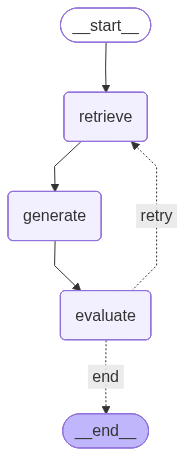

Graph structure:
  START
    └── retrieve (search vector store for relevant chunks)
          └── generate (LLM produces an answer from the chunks)
                └── evaluate (check answer quality)
                      ├── [sufficient] → END
                      └── [retry]      → retrieve (LOOP BACK, up to 3 times)


In [16]:
from IPython.display import Image, display

try:
    img_bytes = retry_graph.get_graph().draw_mermaid_png()
    display(Image(img_bytes))
except Exception as e:
    print(f'(Visual rendering unavailable: {e})')

print('Graph structure:')
print('  START')
print('    └── retrieve (search vector store for relevant chunks)')
print('          └── generate (LLM produces an answer from the chunks)')
print('                └── evaluate (check answer quality)')
print('                      ├── [sufficient] → END')
print('                      └── [retry]      → retrieve (LOOP BACK, up to 3 times)')


## Run the Retry Graph with State Tracing

Watch the state evolve across loop iterations below. If the first answer is good, the graph exits immediately -- you will see `retrieve --> generate --> evaluate --> END` in a single pass. If the evaluator is not satisfied, you will see the loop fire: `retrieve --> generate --> evaluate --> retrieve --> ...` until the answer is sufficient or 3 attempts are reached. The `attempts` counter in the state tracks progress and prevents infinite loops, which is a critical safety feature for any production loop pattern.

In [17]:
if has_llm_provider():
    question = "What was Acme Analytics' revenue in Q4 2025?"
    print(f'Question: "{question}"')
    print()

    iteration = 0
    for state_update in retry_graph.stream({'question': question, 'attempts': 0, 'is_sufficient': False}):
        node_name = list(state_update.keys())[0]
        node_output = state_update[node_name]
        iteration += 1
        print(f'--- Step {iteration}: node "{node_name}" ---')
        for key, value in node_output.items():
            val_str = str(value)
            if len(val_str) > 200:
                val_str = val_str[:200] + '...'
            print(f'  state["{key}"] = {val_str}')
        print()

    print('Graph finished.')


Question: "What was Acme Analytics' revenue in Q4 2025?"

--- Step 1: node "retrieve" ---
  state["context"] = ACME ANALYTICS — Q4 2025 FINANCIAL RESULTS (CONFIDENTIAL)

Period: October 1 – December 31, 2025

Revenue:          $12.8 million (Q4) / $42.3 million (FY 2025)
Gross Margin:     78.2%
Operating Profi...
  state["sources"] = ['acme_docs/company_overview.txt', 'acme_docs/q4_2025_financials.txt', 'acme_docs/products_and_services.txt']

--- Step 2: node "generate" ---
  state["answer"] = $12.8 million

  [evaluate] RETRY (attempt 1)
--- Step 3: node "evaluate" ---
  state["is_sufficient"] = False
  state["attempts"] = 1

  [retry_retrieve] Attempt 2, broadened query
--- Step 4: node "retrieve" ---
  state["context"] = ACME ANALYTICS — Q4 2025 FINANCIAL RESULTS (CONFIDENTIAL)

Period: October 1 – December 31, 2025

Revenue:          $12.8 million (Q4) / $42.3 million (FY 2025)
Gross Margin:     78.2%
Operating Profi...
  state["sources"] = ['acme_docs/company_overview.txt', 'acme_

### Key Takeaways: Why LangGraph for Routing?

| Pattern | Tool | How it works |
|---|---|---|
| Simple RAG | LangChain `RetrievalQA` or LlamaIndex | Fixed pipeline: retrieve → generate |
| Graph RAG | LangGraph (Section 3-6 above) | Explicit nodes, visible state, same fixed flow |
| **Conditional routing** | **LangGraph (this section)** | **LLM classifies → graph branches to specialized handlers** |
| Agent with tools | LangChain Agent (see LangChain notebook) | LLM decides which tools to call at each step |

**When to use conditional routing:**
- Customer support: route tickets to billing, technical, or account teams
- Enterprise search: route queries to different knowledge bases (legal, engineering, HR)
- Multi-model pipelines: use a cheap model for classification, expensive model for generation
- Compliance: ensure sensitive questions always go through an approved handler